<a href="https://colab.research.google.com/github/Rohidhs/Project/blob/main/AI_driven_optimization_of_renewable_energy_grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import datetime

In [ ]:
# Simulate energy data (replace this with real data for more accurate predictions)
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', end='2023-01-15', freq='H')
data = pd.DataFrame(date_rng, columns=['timestamp'])
data['temperature'] = np.random.normal(25, 5, len(data))
data['solar_irradiance'] = np.clip(np.sin(np.linspace(0, 50, len(data))) * 1000 + np.random.normal(0, 100, len(data)), 0, 1000)
data['wind_speed'] = np.clip(np.random.normal(15, 5, len(data)), 0, 30)
data['hydro_flow'] = np.clip(np.random.normal(10, 3, len(data)), 0, 20)
data['energy_demand'] = np.clip(np.random.normal(500, 150, len(data)), 300, 1000)

<ipython-input-3-e91248a450f6>:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='2023-01-01', end='2023-01-15', freq='H')


In [ ]:
# Power generation assumptions (just for simulation)
data['solar_output'] = np.clip(data['solar_irradiance'] * 0.2 + np.random.normal(0, 10, len(data)), 0, 200)
data['wind_output'] = np.clip(data['wind_speed'] * 10 + np.random.normal(0, 10, len(data)), 0, 150)
data['hydro_output'] = np.clip(data['hydro_flow'] * 5 + np.random.normal(0, 10, len(data)), 0, 100)

In [ ]:
# Feature engineering
data['hour'] = data['timestamp'].dt.hour
data['day'] = data['timestamp'].dt.day
features = ['temperature', 'solar_irradiance', 'wind_speed', 'hydro_flow', 'hour', 'day']
target_solar = 'solar_output'
target_wind = 'wind_output'
target_hydro = 'hydro_output'
target_demand = 'energy_demand'

In [ ]:
# 2. Model: Solar Power Forecasting
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(data[features], data[target_solar], test_size=0.2, random_state=42)
model_solar = XGBRegressor()
model_solar.fit(X_train, y_train)
pred_solar = model_solar.predict(X_test)

In [ ]:
# 3. Model: Wind Power Forecasting
# ---------------------------
X_train_wind, X_test_wind, y_train_wind, y_test_wind = train_test_split(data[features], data[target_wind], test_size=0.2, random_state=42)
model_wind = XGBRegressor()
model_wind.fit(X_train_wind, y_train_wind)
pred_wind = model_wind.predict(X_test_wind)

In [ ]:
# 4. Model: Hydro Power Forecasting
# ---------------------------
X_train_hydro, X_test_hydro, y_train_hydro, y_test_hydro = train_test_split(data[features], data[target_hydro], test_size=0.2, random_state=42)
model_hydro = XGBRegressor()
model_hydro.fit(X_train_hydro, y_train_hydro)
pred_hydro = model_hydro.predict(X_test_hydro)

In [ ]:
# 5. Model: Energy Demand Forecasting
# ---------------------------
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(data[features], data[target_demand], test_size=0.2, random_state=42)
model_demand = XGBRegressor()
model_demand.fit(X_train_d, y_train_d)
pred_demand = model_demand.predict(X_test_d)

In [ ]:
# 6. Battery Optimization Logic (Based on Net Energy)
# ---------------------------
battery_capacity = 1000  # in kWh
battery_charge = 500     # initial charge
charge_log = []

for i in range(len(X_test)):
    solar = pred_solar[i]
    wind = pred_wind[i]
    hydro = pred_hydro[i]
    demand = pred_demand[i]

    # Total renewable energy generation
    total_generation = solar + wind + hydro
    net_energy = total_generation - demand  # Net energy: generation - demand

    # Simple control: store surplus energy, draw from battery when needed
    if net_energy > 0:
        battery_charge = min(battery_capacity, battery_charge + net_energy * 0.9)  # Store 90% of surplus
    else:
        battery_charge = max(0, battery_charge + net_energy)  # Discharge battery if negative balance

    charge_log.append(battery_charge)

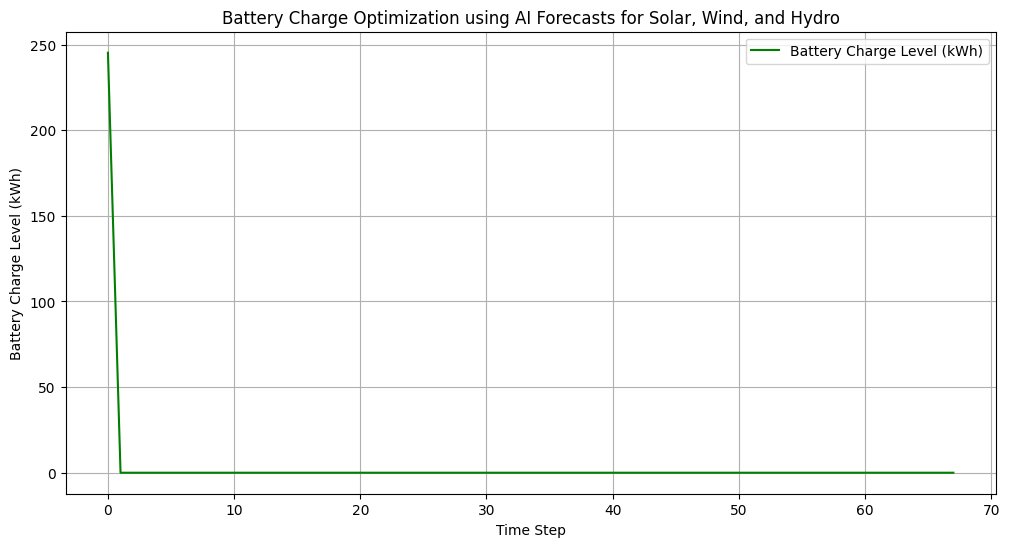

In [ ]:
# 7. Visualization of Battery Charge Over Time
# ---------------------------
plt.figure(figsize=(12, 6))
plt.plot(range(len(charge_log)), charge_log, label='Battery Charge Level (kWh)', color='green')
plt.xlabel("Time Step")
plt.ylabel("Battery Charge Level (kWh)")
plt.title("Battery Charge Optimization using AI Forecasts for Solar, Wind, and Hydro")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 8. Evaluation: RMSE of Predictions
# ---------------------------
# Calculate Mean Squared Error (MSE) first
mse_solar = mean_squared_error(y_test, pred_solar)
mse_wind = mean_squared_error(y_test_wind, pred_wind)
mse_hydro = mean_squared_error(y_test_hydro, pred_hydro)
mse_demand = mean_squared_error(y_test_d, pred_demand)

# Calculate RMSE by taking the square root of MSE
rmse_solar = np.sqrt(mse_solar)
rmse_wind = np.sqrt(mse_wind)
rmse_hydro = np.sqrt(mse_hydro)
rmse_demand = np.sqrt(mse_demand)

# Print the results
print("Solar Forecast RMSE:", rmse_solar)
print("Wind Forecast RMSE:", rmse_wind)
print("Hydro Forecast RMSE:", rmse_hydro)
print("Demand Forecast RMSE:", rmse_demand)


Solar Forecast RMSE: 8.8776715816083
Wind Forecast RMSE: 7.345899333228435
Hydro Forecast RMSE: 11.835613429128767
Demand Forecast RMSE: 162.95856393511167
